# Part 1: Comparing Backends

In [1]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
device = "cuda" if torch.cuda.is_available() else "cpu"
class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024),
            nn.ReLU(),
            nn.Linear(1024, 1024)
        )

    def forward(self, x):
        return self.net(x)
model = SimpleNet().to(device)
x = torch.randn(1024,1024,device=device)
backends = [
    "eager",
    "aot_eager",
    "inductor",
    "cudagraphs"
]
times = []
for backend in backends:
    if backend == "eager":
        compiled_model = model
    else:
        compiled_model = torch.compile(model, backend=backend)
    start = time.time()
    for _ in range(100):
        y = compiled_model(x)
        loss = y.sum()
        loss.backward()
    torch.cuda.synchronize() if device=="cuda" else None
    end = time.time()
    times.append((end-start)/100)
print(dict(zip(backends,times)))


/usr/local/lib/python3.12/dist-packages/torch/_inductor/compile_fx.py:321: UserWarning: TensorFloat32 tensor cores for float32 matrix multiplication available but not enabled. Consider setting `torch.set_float32_matmul_precision('high')` for better performance.
  warnings.warn(


{'eager': 0.004854638576507569, 'aot_eager': 0.015146751403808594, 'inductor': 0.03433224678039551, 'cudagraphs': 0.002107677459716797}


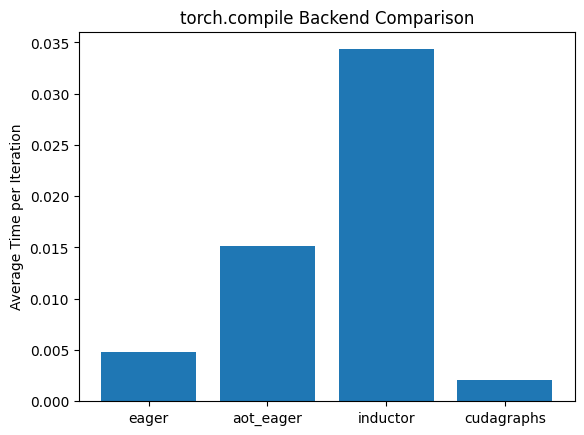

In [2]:
plt.bar(backends,times)
plt.ylabel("Average Time per Iteration")
plt.title("torch.compile Backend Comparison")
plt.show()

The graph compares the average execution time of different PyTorch compilation backends.

The **eager backend** runs operations one by one without compilation, so it has moderate performance.

The **aot_eager backend** traces the computation graph but still runs operations using eager kernels, so it is slightly slower.

The **inductor backend** performs heavy compilation and optimisation. In this experiment it appears slower because compilation overhead is included.

The **cudagraphs backend** records the execution graph and reduces kernel launch overhead, which gives the fastest performance in this experiment.

Overall, different backends have different performance because they use different optimisation techniques and have different compilation overhead.


# Part 2: Debugging Compilation Failures

In [7]:
#Problem Functions
def problem1(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2

def problem2(x):
    d = {}
    d["key"] = x
    return d["key"] * 2

def problem3(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result


In [8]:
#Compilation
compiled1 = torch.compile(problem1)
compiled2 = torch.compile(problem2)
compiled3 = torch.compile(problem3)

In [6]:
import torch._dynamo as dynamo

print(dynamo.explain(problem1)(torch.randn(4,4)))


Graph Count: 2
Graph Break Count: 1
Op Count: 2
Break Reasons:
  Break Reason 1:
    Reason: generic_jump TensorVariable()
    User Stack:
      <FrameSummary file /tmp/ipykernel_159/3171497591.py, line 3 in problem1>
Ops per Graph:
  Ops 1:
    <built-in function gt>
  Ops 2:
    <built-in function mul>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.

In [20]:
print(dynamo.explain(problem2)(torch.randn(4,4)))


Graph Count: 1
Graph Break Count: 0
Op Count: 1
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function mul>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.CURRENT_DEVICE == None']
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 5:
    Name: ''
    Source: global
    Create Function: GLOBAL_STATE
    Guard Types: None
    Code L

In [21]:
print(dynamo.explain(problem3)(torch.randn(4,4)))


Graph Count: 1
Graph Break Count: 0
Op Count: 20
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function pow>
    <built-in function add>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
    <built-in function pow>
    <built-in function iadd>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None

### Fixed versions

```python
#Problem Function
def problem1(x):
    if x.sum() > 0:
        return x * 2
    else:
        return x / 2
#fixed Function
def fixed1(x):
    cond = (x.sum() > 0)
    return torch.where(cond, x*2, x/2)
```

Compilation fails because the `if` statement depends on a tensor value.
TorchDynamo cannot trace Python control flow that depends on tensor data, so a graph break occurs.
We can infer it from the above out as ```Graph Break Count: 1
Break Reason: generic_jump TensorVariable()```.The fixed version removes Python control flow and uses a tensor operation (`torch.where`).
This allows TorchDynamo to capture the computation in the graph.


```python
#Problem Function
def problem2(x):
    d = {}
    d["key"] = x
    return d["key"] * 2

# fixed Function
def fixed2(x):
    return x * 2
```

TorchDynamo cannot compile Python dictionaries inside the graph.
Python data structures cause a graph break.The fixed version removes the Python dictionary and directly performs the tensor computation.


```python
#Problem Function
def problem3(x):
    result = 0
    for i in range(10):
        result += (x ** i).sum()
    return result

# fixed Function
def fixed3(x):
    powers = [x**i for i in range(10)]
    return torch.stack(powers).sum()
```
The Python loop causes repeated operations that cannot be efficiently optimised by the compiler.The fixed version vectorises the computation, allowing the compiler to optimise the operations more efficiently.


In [19]:
#Compilation
def fixed1(x):
    cond = (x.sum() > 0)
    return torch.where(cond, x*2, x/2)
def fixed2(x):
    return x * 2

def fixed3(x):
    powers = [x**i for i in range(10)]
    return torch.stack(powers).sum()
compiled1 = torch.compile(fixed1)
compiled2 = torch.compile(fixed2)
compiled3 = torch.compile(fixed3)
import torch._dynamo as dynamo

print(dynamo.explain(fixed1)(torch.randn(4,4)))


Graph Count: 1
Graph Break Count: 0
Op Count: 4
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function gt>
    <built-in function mul>
    <built-in function truediv>
    <built-in method where of type object at 0x7f8c43f82820>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.CURRENT_DEVICE == None']
    Object Weakref: None
    Guarded Class Wea

In [22]:
print(dynamo.explain(fixed2)(torch.randn(4,4)))


Graph Count: 1
Graph Break Count: 0
Op Count: 1
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function mul>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: ''
    Source: global
    Create Function: DEFAULT_DEVICE
    Guard Types: ['DEFAULT_DEVICE']
    Code List: ['utils_device.CURRENT_DEVICE == None']
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 5:
    Name: ''
    Source: global
    Create Function: GLOBAL_STATE
    Guard Types: None
    Code L

In [23]:
print(dynamo.explain(fixed3)(torch.randn(4,4)))


Graph Count: 1
Graph Break Count: 0
Op Count: 11
Break Reasons:
Ops per Graph:
  Ops 1:
    <built-in function pow>
    <built-in function pow>
    <built-in function pow>
    <built-in function pow>
    <built-in function pow>
    <built-in function pow>
    <built-in function pow>
    <built-in function pow>
    <built-in function pow>
    <built-in function pow>
    <built-in method stack of type object at 0x7f8c43f82820>
Out Guards:
  Guard 1:
    Name: ''
    Source: shape_env
    Create Function: SHAPE_ENV
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 2:
    Name: ''
    Source: global
    Create Function: DETERMINISTIC_ALGORITHMS
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 3:
    Name: ''
    Source: global
    Create Function: GRAD_MODE
    Guard Types: None
    Code List: None
    Object Weakref: None
    Guarded Class Weakref: None
  Guard 4:
    Name: '

# Part 3: Graph Capture and Inspection

In [24]:
import torch
import torch.nn.functional as F
x = torch.randn(128,128)
w1 = torch.randn(128,128)
w2 = torch.randn(128,128)
def graph_fn(x, w1, w2):
    y = x @ w1
    y = torch.relu(y)
    y = y @ w2
    y = y + x
    y = F.layer_norm(y, y.shape)
    print("Hello")
    lst = []
    lst.append(1)
    return y

In [25]:
compiled = torch.compile(graph_fn, fullgraph=True)

In [26]:
import torch._dynamo as dynamo
print(dynamo.explain(graph_fn)(x,w1,w2))

Hello
Graph Count: 1
Graph Break Count: 0
Op Count: 5
Break Reasons:
  Break Reason 1:
    Reason: Failed to trace builtin operator
  Explanation: Dynamo does not know how to trace builtin operator `print` with argument types ['str'] (has_kwargs False)
  Hint: Avoid calling builtin `print` with argument types ['str']. Consider using an equivalent alternative function/method to `print`.
  Hint: If you are attempting to call a logging function (e.g. `print`), you can try adding it to `torch._dynamo.config.reorderable_logging_functions`.
  Hint: Please report an issue to PyTorch.

  Developer debug context: builtin print [<class 'torch._dynamo.variables.constant.ConstantVariable'>] False

 For more details about this graph break, please visit: https://meta-pytorch.github.io/compile-graph-break-site/gb/gb0059.html
    User Stack:
      <FrameSummary file /tmp/ipykernel_159/661038704.py, line 12 in graph_fn>
Ops per Graph:
  Ops 1:
    <built-in function matmul>
    <built-in method relu of

### Graph Capture Results

The output from `torch._dynamo.explain()` shows:

- Graph Count: 1  
- Graph Break Count: 0  
- Operation Count: 5  

Captured operations in the graph:

1. matrix multiplication (matmul)
2. ReLU activation
3. matrix multiplication
4. addition (residual connection)
5. layer normalization

### Operations Not Captured

The `print("Hello")` statement was not captured in the computation graph.

Reason:
TorchDynamo cannot trace Python side effect operations such as `print`.  
These operations are executed outside the compiled graph.

### Python Side Effects

Python operations such as:

- `print()`  
- modifying a Python list (`append`)

are not part of tensor computation and therefore cannot be included in the compiled graph.


In [27]:
from torch.fx import symbolic_trace

traced = symbolic_trace(graph_fn)
print(traced.graph)


Hello
graph():
    %x : [num_users=2] = placeholder[target=x]
    %w1 : [num_users=1] = placeholder[target=w1]
    %w2 : [num_users=1] = placeholder[target=w2]
    %matmul : [num_users=1] = call_function[target=operator.matmul](args = (%x, %w1), kwargs = {})
    %relu : [num_users=1] = call_function[target=torch.relu](args = (%matmul,), kwargs = {})
    %matmul_1 : [num_users=1] = call_function[target=operator.matmul](args = (%relu, %w2), kwargs = {})
    %add : [num_users=2] = call_function[target=operator.add](args = (%matmul_1, %x), kwargs = {})
    %getattr_1 : [num_users=1] = call_function[target=builtins.getattr](args = (%add, shape), kwargs = {})
    %layer_norm : [num_users=1] = call_function[target=torch.nn.functional.layer_norm](args = (%add, %getattr_1), kwargs = {weight: None, bias: None, eps: 1e-05})
    return layer_norm
